# 10 — Wheel and slip

**The tire is an actuator too, and it saturates.**

Every notebook so far has drawn the same three-step picture: the engine makes torque, the
driveline carries it to the road, and the car accelerates. The third step has been free.
Whatever force the driveline asked the road for, the road supplied.

Nothing in this lecture has ever said that out loud, which is exactly the problem. It is an
assumption; it is the assumption that fails first on a real road; and when it fails, the
controller that has looked competent for nine notebooks does not notice, because the signal
that has gone wrong is not one it measures.

Three beats. A wheel that can spin. The curve that explains why, once it starts, it keeps
spinning. And the cruise control from notebook 06, holding 90 km/h onto a stretch of ice.

## Setup

Same bootstrap as every notebook in this set.

In [1]:
isdefined(Main, :Lecture01Support) || include("support.jl")

# Bound by hand rather than with `using`. If this kernel ever ran an earlier `include` of
# support.jl there are two copies of the module, every name both export is ambiguous, and no
# amount of re-running `using` resolves it. An explicit binding does, so this cell repairs a
# kernel in that state instead of needing it restarted. Editing support.jl still needs a
# restart, because the guard above deliberately will not load a second copy.
for n in names(Lecture01Support)
    n === :Lecture01Support && continue
    Core.eval(Main, :($n = Lecture01Support.$n))
end

In [2]:
setup()

Main.VehicleSystemsComponents

## 1. The wheel appears

The plant in notebooks 01 to 09 has no rotating inertia between the engine and the road. Torque
arrives at the gearbox and leaves as a force on a mass; the wheel is a lever arm, not a body.

`Lecture1.WheeledCarPlant` — call it L1 — puts a road wheel there: one rotating inertia of
`J_w = 1 kg.m^2`, turning at the speed the car's motion demands. It still assumes the contact
patch does not slide, so the wheel's rotation and the car's translation remain locked to each
other by `v = omega * r`. Nothing about the control problem has changed. The only question this
first cell asks is whether the gains still work, and by how much the response moves if they do.

The step is notebook 05's: 90 to 110 km/h, PID at `k = 56`, `Ti = 10 s`, `Td = 0.5 s`, with the
torque ceiling lifted exactly as notebooks 03 to 05 lifted it.

Sources: [`dyad/Lecture1/WheeledCarPlant.dyad`](../../dyad/Lecture1/WheeledCarPlant.dyad) and
the driveline it uses,
[`dyad/Vehicle/WheeledDriveline.dyad`](../../dyad/Vehicle/WheeledDriveline.dyad).

                   rise 10-90 %   settling to 0.4 km/h   overshoot   settled
  L0, no wheel    1.263 s        9.38 s                 3.07 %      110.001 km/h
  L1, wheel       1.299 s        9.49 s                 3.1 %       110.001 km/h

  the wheel costs 2.9 % of rise time and 1.2 % of settling time


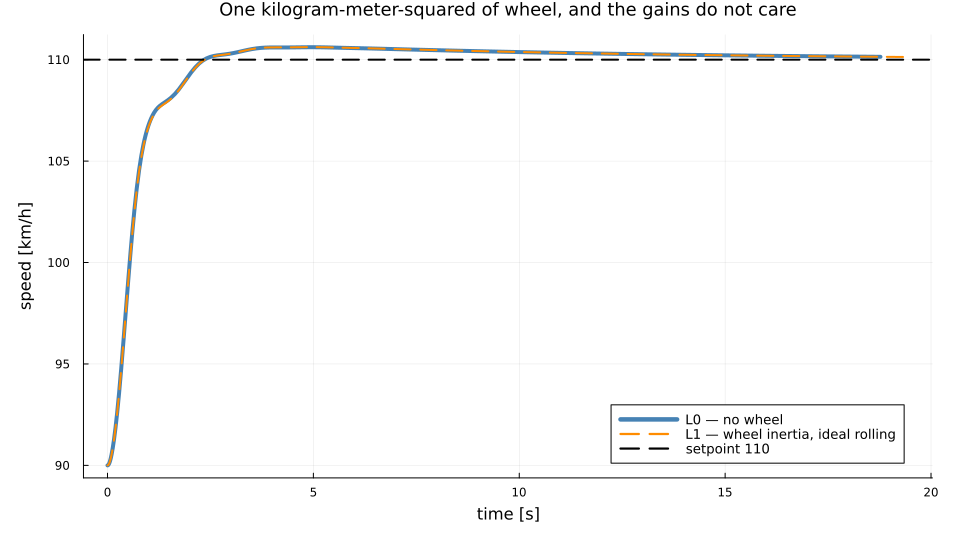

In [3]:
Scenarios = VehicleSystemsComponents.Lecture1

SPEED_L0  = "loop.plant.v_kmh"   # the L0 harness wraps its loop in a scenario
SPEED_L1  = "plant.v_kmh"        # the L1 harness is the loop
V_START   = 90.0                 # km/h
SETPOINT  = 110.0                # km/h
GAIN      = 56.0                 # N.m per km/h
T_I       = 10.0                 # s
T_D       = 0.5                  # s
UNLIMITED = 1.0e6                # N.m — the ceiling stays lifted, as in notebooks 03 to 05

pid_step(; with_I, with_D) =
    Scenarios.CruiseLoopStep(; name = :CruiseLoopStep, with_I = with_I, with_D = with_D)

l0 = rerun(
    Scenarios.CruiseLoopTransient(
        model = pid_step(with_I = true, with_D = true),
        k = GAIN, Ti = T_I, Td = T_D, wd = 0.0,
        T_max = UNLIMITED, y_max = UNLIMITED, stop = 60.0),
    "loop.controller.xd0" => -V_START)

l1 = Scenarios.WheeledCruiseTransient(
    k = GAIN, Ti = T_I, Td = T_D, wd = 0.0,
    T_max = UNLIMITED, y_max = UNLIMITED, stop = 60.0)

# Last sample outside the band, not the first one inside it: this response re-enters the band
# before it has finished crossing the setpoint, so the first entry measures the overshoot
# rather than the settling.
settling_time(t, y, target; band) =
    (i = findlast(v -> abs(v - target) > band, y); isnothing(i) ? 0.0 : t[i])

t0, y0 = signal(l0, SPEED_L0)
t1, y1 = signal(l1, SPEED_L1)

println("                   rise 10-90 %   settling to 0.4 km/h   overshoot   settled")
for (name, t, y) in (("L0, no wheel ", t0, y0), ("L1, wheel    ", t1, y1))
    println("  ", name,
            "   ", rpad(string(round(rise_time(t, y, SETPOINT), digits = 3), " s"), 15),
            "", rpad(string(round(settling_time(t, y, SETPOINT; band = 0.4), digits = 2), " s"), 23),
            "", rpad(string(round(overshoot(t, y, SETPOINT), digits = 2), " %"), 12),
            round(y[end], digits = 3), " km/h")
end

shift(f) = 100 * (f(t1, y1) - f(t0, y0)) / f(t0, y0)
println()
println("  the wheel costs ", round(shift((t, y) -> rise_time(t, y, SETPOINT)), digits = 1),
        " % of rise time and ",
        round(shift((t, y) -> settling_time(t, y, SETPOINT; band = 0.4)), digits = 1),
        " % of settling time")

WINDOW = (0.0, 20.0)
keep(t, y, lo, hi) = (m = lo .<= t .<= hi; (t[m], y[m]))

plt = plot(keep(t0, y0, WINDOW...)...; lw = 4, color = :steelblue, label = "L0 — no wheel",
           xlabel = "time [s]", ylabel = "speed [km/h]", legend = :bottomright,
           title = "One kilogram-meter-squared of wheel, and the gains do not care")
plot!(plt, keep(t1, y1, WINDOW...)...; lw = 2, ls = :dash, color = :darkorange,
      label = "L1 — wheel inertia, ideal rolling")
hline!(plt, [SETPOINT]; ls = :dash, lw = 2, color = :black, label = "setpoint 110")
plt

The gains carry over, and they carry over almost exactly. The two traces are one trace at the
width of a pen stroke: the wheel adds a few percent to the rise and rather less than that to
the settling, and every other readout is unchanged to three figures.

That is the expected result, and it is worth being clear about why, because the next section
will look like it contradicts it. Wheel inertia is a *load*. It makes the plant slightly
heavier to accelerate — `J_w/r^2` is about 10 kg of apparent mass against the car's 1400 — and
a slightly heavier plant is a slightly slower plant. A PID controller absorbs that without
being retuned, which is most of what a PID controller is for.

### The equation that was doing the work

L1 is not a better model of the contact patch. It is the same model of the contact patch with
a flywheel bolted to it. `WheeledDriveline` ties rotation to translation with one equation,

    v = omega * r

and that equation is not physics. It is a *constraint*, asserted, and it says that the tire
cannot slide. Whatever force is needed to keep the car's speed and the wheel's speed locked
together, the road provides — 400 N to hold 90 km/h, 2000 N at full throttle, and it would
provide 20 000 N if the equation demanded it.

Real roads do not work that way, and the disagreement is not small. Tires transmit force
*because* they slide, a little: the contact patch deforms, the tread elements at its trailing
edge slip, and the wheel therefore turns slightly faster than the car is traveling. The
measure of that difference is the **slip ratio**,

    kappa = (omega * r - v) / |v|

which is zero for a wheel rolling free, positive for a wheel driving the car forward, and
unbounded for a wheel spinning on ice. `v = omega * r` is the statement `kappa = 0`, imposed.

`Vehicle.SlipWheel1D` deletes that constraint and puts a friction law in its place. The wheel
and the car are now two separate bodies coupled only by the force the contact can actually
carry, and how much that is depends on `kappa` and on how slippery the road is.

In [4]:
show_dyad("SlipWheel1D")

SlipWheel1D — dyad/Vehicle/SlipWheel1D.dyad line 1 
 """
One-dimensional tire contact with longitudinal slip-dependent friction.

Positive shaft rotation drives positive vehicle motion. The friction law uses the same point-
symmetric triple-S shape as `MultibodyComponents.SlipWheelJoint`: it rises to `mu_A` at
`sAdhesion`, falls to `mu_S` at `sSlide`, and remains at the sliding level beyond it. `F_z` is
the normal load carried by the modeled driven axle; approximately half the vehicle weight is a
representative default for a single driven axle.

The curve is continuously differentiable but has a discontinuous second derivative at its
transitions. Explicit Runge-Kutta solvers generally handle it better than BDF methods.
"""
component SlipWheel1D
 "Wheel shaft"
 spline = Spline()
 "Longitudinal connection to the vehicle body"
 flange = Flange()
 "Road-friction multiplier"
 mu_scale = RealInput()
 "Wheel rolling radius"
 parameter radius::Length = 0.31
 "Normal load carried by the driven axle"
 parameter F_z::Force = 6864.655
 "Slip ratio at peak adhesion"
 parameter sAdhesion::Real = 0.04
 "Slip ratio at the sliding plateau"
 parameter sSlide::Real = 0.12
 "Peak adhesion coefficient"
 parameter mu_A::Real = 1.0
 "Sliding friction coefficient"
 parameter mu_S::Real = 0.7
 "Low-speed denominator floor; 0.5 m/s avoids singular standstill slip without masking launch dynamics"
 parameter v_eps::Velocity = 0.5
 "Wheel angular speed"
 variable omega::AngularVelocity
 "Vehicle longitudinal speed"
 variable v::Velocity
 "Regularized longitudinal slip ratio"
 variable kappa::Real
 "Signed friction coefficient after road scaling"
 variable mu::Real
 "Longitudinal tire force"
 variable F_x::Force
relations
 omega = der(spline.phi)
 v = der(flange.s)
 kappa = (omega * radius - v) / max(abs(v), v_eps)
 # This is the triple-S interpolation used by the multibody wheel, written locally so the
 # lightweight 1D lecture model does not acquire a multibody dependency.
 mu = mu_scale * ifelse(kappa > sAdhesion,
 ifelse(kappa >= sSlide, mu_S,
 (mu_A + mu_S) / 2 + (mu_S - mu_A) / 2 *
 (-0.5 * ((kappa - (sAdhesion + sSlide) / 2) * 2 / (sSlide - sAdhesion)) ^ 3 +
 1.5 * ((kappa - (sAdhesion + sSlide) / 2) * 2 / (sSlide - sAdhesion)))),
 ifelse(kappa < -sAdhesion,
 ifelse(kappa <= -sSlide, -mu_S,
 -(mu_A + mu_S) / 2 - (mu_S - mu_A) / 2 *
 (-0.5 * ((-kappa - (sAdhesion + sSlide) / 2) * 2 / (sSlide - sAdhesion)) ^ 3 +
 1.5 * ((-kappa - (sAdhesion + sSlide) / 2) * 2 / (sSlide - sAdhesion)))),
 mu_A * (-0.5 * (kappa / sAdhesion) ^ 3 + 1.5 * kappa / sAdhesion)))
 F_x = mu * F_z
 # Flow is positive into this component. The tire therefore reports negative flange force while
 # applying positive traction to the connected body; the shaft sees the matching resisting torque.
 flange.f = -F_x
 0 = spline.tau + radius * flange.f
end

Two things in that declaration matter more than the algebra.

**`F_x = mu * F_z` is a ceiling on the force the road can supply**, and `F_z` is the load on the
driven axle — roughly half the car's weight, about 6.9 kN. On dry asphalt `mu` peaks at about
1, so the ceiling is near 6.9 kN and the engine's 1935 N of tractive force never approaches it.
On ice, `mu_scale` scales the whole curve down, and the ceiling can fall below what the car
needs merely to hold its speed.

**The friction law is a function of `kappa` alone**, and it is not monotonic. That second fact
is the whole of section 3.

## 2. Wheelspin, and why one plot of it proves nothing

The first beat is a standing start at full throttle on low friction, run open loop —
`Lecture1.SlipCarPlant` with a constant 150 N.m of command, a flat road and one friction
number, which is the harness the model's own test case uses.

One run of that is not an argument. A wheel that runs away while the car stays put is exactly
what a sign error in the coupling looks like, and it is exactly what a mistyped inertia looks
like. So the cell below runs it twice — once on packed snow at `mu_scale = 0.2`, once on dry
asphalt at `mu_scale = 1.0` — and changes nothing else. The second run is the control, and
without it the first one means nothing.

Sources: [`dyad/Lecture1/SlipCarPlant.dyad`](../../dyad/Lecture1/SlipCarPlant.dyad), which is
`Vehicle.SlipWheel1D` between the gearbox and the car body.

  after 5 s at full throttle from rest
                        car [km/h]   wheel [rpm]   slip ratio   tire force [N]
  mu_scale = 0.2 — snow 10.117       12843.1       147.3509     961.1
  mu_scale = 1.0 — dry  21.077       181.7         0.0076       1922.4

  on snow the tire peaks at 1373 N, which is every newton the surface has, and settles at 961 N once it is sliding


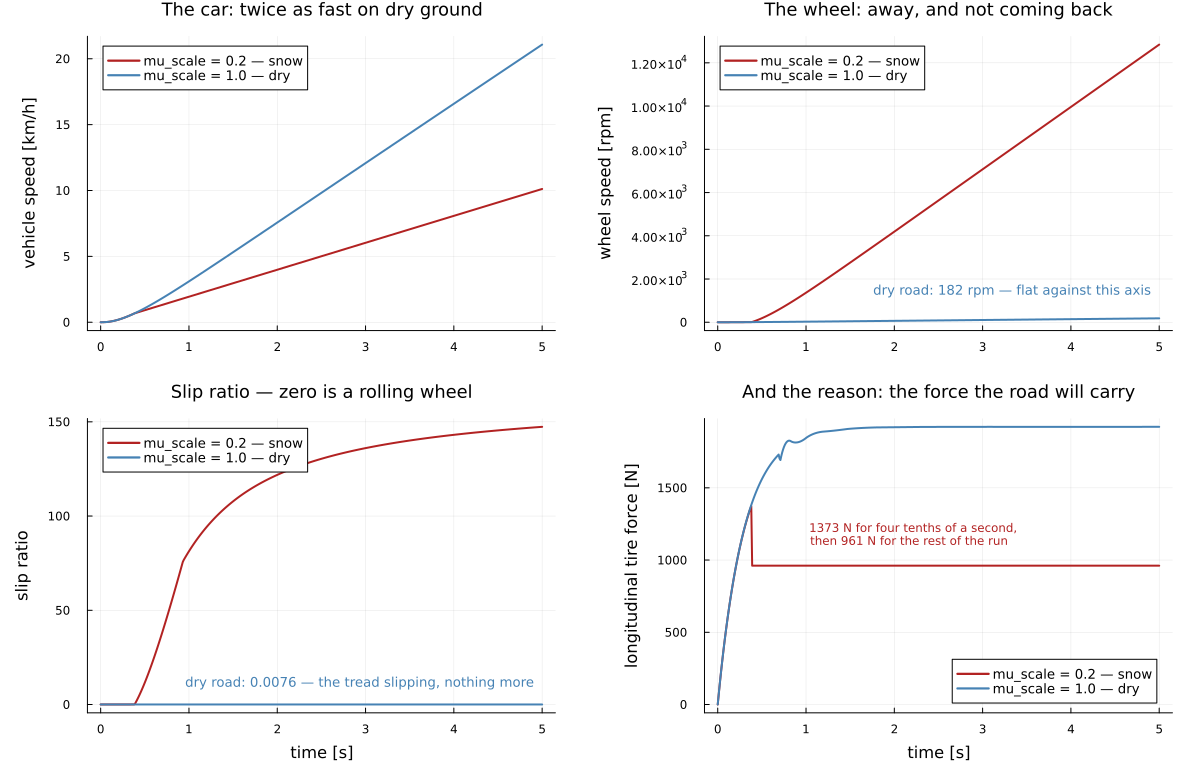

In [5]:
@named standing = Scenarios.TestSlipCarPlant()

MU_SNOW = 0.2       # packed snow
MU_DRY  = 1.0       # dry asphalt
LAUNCH  = (0.0, 5.0)

# `saveat` here is dense output, not decimation. The adaptive solver keeps about sixty samples
# across these five seconds and the launch transient is over inside one of them, so the raw
# step points draw a curve the eye reads as straight lines.
launch = sweep(standing, "friction.k", [MU_SNOW, MU_DRY]; tspan = LAUNCH, saveat = 0.01)
runs = Dict(launch.values .=> launch.sols)

RUNS = ((MU_SNOW, "mu_scale = 0.2 — snow", :firebrick),
        (MU_DRY,  "mu_scale = 1.0 — dry",  :steelblue))

println("  after 5 s at full throttle from rest")
println("                        car [km/h]   wheel [rpm]   slip ratio   tire force [N]")
for (mu, label, _) in RUNS
    sol = runs[mu]
    at_end(p) = signal(sol, p)[2][end]
    println("  ", rpad(label, 22),
            rpad(round(at_end("plant.v_kmh"), digits = 3), 13),
            rpad(round(at_end("plant.wheel_rpm"), digits = 1), 14),
            rpad(round(at_end("plant.kappa"), digits = 4), 13),
            round(at_end("plant.wheel.F_x"), digits = 1))
end

_, force_snow = signal(runs[MU_SNOW], "plant.wheel.F_x")
println()
println("  on snow the tire peaks at ", round(Int, maximum(force_snow)),
        " N, which is every newton the surface has, and settles at ",
        round(Int, force_snow[end]), " N once it is sliding")

speed = plot(; ylabel = "vehicle speed [km/h]", legend = :topleft,
             title = "The car: twice as fast on dry ground")
wheel = plot(; ylabel = "wheel speed [rpm]", legend = :topleft,
             title = "The wheel: away, and not coming back")
slip  = plot(; xlabel = "time [s]", ylabel = "slip ratio", legend = :topleft,
             title = "Slip ratio — zero is a rolling wheel")
force = plot(; xlabel = "time [s]", ylabel = "longitudinal tire force [N]",
             legend = :bottomright, title = "And the reason: the force the road will carry")

for (mu, label, hue) in RUNS
    sol = runs[mu]
    plot!(speed, signal(sol, "plant.v_kmh")...;    lw = 2, color = hue, label = label)
    plot!(wheel, signal(sol, "plant.wheel_rpm")...; lw = 2, color = hue, label = label)
    plot!(slip,  signal(sol, "plant.kappa")...;     lw = 2, color = hue, label = label)
    plot!(force, signal(sol, "plant.wheel.F_x")...; lw = 2, color = hue, label = label)
end

dry(p) = signal(runs[MU_DRY], p)[2][end]
annotate!(wheel, 4.9, 1500,
          text("dry road: $(round(Int, dry("plant.wheel_rpm"))) rpm — flat against this axis",
               9, :right, :steelblue))
annotate!(slip, 4.9, 12,
          text("dry road: $(round(dry("plant.kappa"), digits = 4)) — the tread slipping, nothing more",
               9, :right, :steelblue))
annotate!(force, 1.05, 1180,
          text("$(round(Int, maximum(force_snow))) N for four tenths of a second,\n" *
               "then $(round(Int, force_snow[end])) N for the rest of the run",
               8, :left, :firebrick))

wheelspin = plot(speed, wheel, slip, force; layout = (2, 2), size = (1200, 780))
save_figure(wheelspin, "10-wheelspin")
wheelspin

Same command, same car, same five seconds. The only thing that changed is a number multiplying
the friction coefficient, and the two runs are not variations on a theme — they are different
kinds of event.

On dry asphalt the wheel turns at 182 rpm, which is the speed a wheel turns when it is rolling
along a road at 21 km/h. The slip ratio is 0.0076: the contact patch is slipping by three
quarters of one percent, which is what a tire does when it is working properly. The force is
1 922 N, within a percent of the 1 935 N that the engine's 150 N.m produces through a 4:1
reduction on a 0.31 m radius — the road gave the driveline what it asked for, because it had
6.9 kN available and was asked for two.

On snow the wheel reaches 12 843 rpm and the car reaches 10 km/h. The slip ratio is 147 — the
wheel's surface is moving a hundred and forty-seven times faster than the car. And the force
panel says why the car is slow: 961 N, half of what the dry road supplied, from a tire that is
spinning seventy times faster.

That panel is worth a second look, because it contains the whole argument in one step. For the
first four tenths of a second the two traces are the same trace: the engine's torque is still
climbing through its lag, and both surfaces carry every newton of it without complaint. Then
the snow hits 1 373 N — everything it has — and falls off a cliff to 961 N, where it stays for
the rest of the run, while the dry road goes on climbing. Nothing changed about the road. What
changed is that the tire went past something.

**More wheel speed bought less force.** That is the sentence to take into the next section,
and it is not what anyone's intuition says about pressing an accelerator harder.

## 3. The friction curve, and the loop inside the plant

The friction law is worth plotting on its own, away from any simulation, because everything
above is a consequence of its shape.

The curve below is not a formula retyped into the notebook — it is the `mu` equation lifted out
of `Vehicle.SlipWheel1D`, with the component's own parameters substituted in and the result
compiled into a callable. If the model changes, this plot changes with it.

  peak adhesion   mu = 1.0 at kappa = 0.04
  sliding plateau mu = 0.7  — 30.0 % of the peak thrown away

  kappa      mu (dry)   mu (snow)
  0.0        0.0        0.0
  0.01       0.3672     0.0734
  0.04       1.0        0.2
  0.08       0.85       0.17
  0.12       0.7        0.14
  0.5        0.7        0.14
  147.35     0.7        0.14


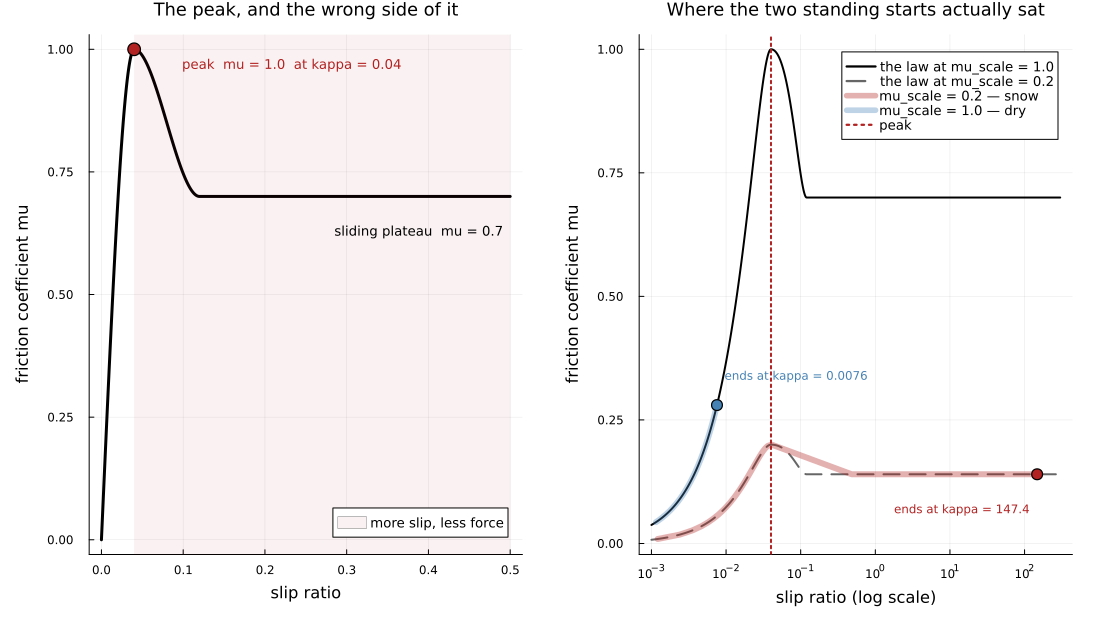

In [6]:
wheel_model = complete(VehicleSystemsComponents.Vehicle.SlipWheel1D(name = :wheel))
mu_law = only(eq for eq in equations(wheel_model) if isequal(eq.lhs, wheel_model.mu))

mu_of = build_function(
    substitute(mu_law.rhs, Dict{Any, Any}(initial_conditions(wheel_model))),
    wheel_model.kappa, wheel_model.mu_scale; expression = Val(false))

kappas = range(0.0, 0.5; length = 2001)
dry_curve = mu_of.(kappas, MU_DRY)
peak_kappa = kappas[argmax(dry_curve)]
MU_PEAK = maximum(dry_curve)
MU_SLIDE = last(dry_curve)

println("  peak adhesion   mu = ", round(MU_PEAK, digits = 4), " at kappa = ",
        round(peak_kappa, digits = 4))
println("  sliding plateau mu = ", round(MU_SLIDE, digits = 4),
        "  — ", round(100 * (1 - MU_SLIDE / MU_PEAK), digits = 1), " % of the peak thrown away")
println()
println("  kappa      mu (dry)   mu (snow)")
for k in (0.0, 0.01, peak_kappa, 0.08, 0.12, 0.5, 147.35)
    println("  ", rpad(round(k, digits = 4), 11),
            rpad(round(mu_of(k, MU_DRY), digits = 4), 11),
            round(mu_of(k, MU_SNOW), digits = 4))
end

curve = plot(kappas, dry_curve; lw = 3, color = :black, label = "",
             xlabel = "slip ratio", ylabel = "friction coefficient mu",
             title = "The peak, and the wrong side of it", legend = :bottomright)
vspan!(curve, [peak_kappa, 0.5]; color = :firebrick, alpha = 0.06,
       label = "more slip, less force")
scatter!(curve, [peak_kappa], [MU_PEAK]; ms = 7, color = :firebrick, label = "")
annotate!(curve, peak_kappa + 0.06, 0.97,
          text("peak  mu = $(round(MU_PEAK, digits = 2))  at kappa = $(round(peak_kappa, digits = 2))",
               9, :left, :firebrick))
annotate!(curve, 0.49, MU_SLIDE - 0.07,
          text("sliding plateau  mu = $(round(MU_SLIDE, digits = 2))", 9, :right, :black))

DECADES = exp10.(-3:2)
grid = exp10.(range(-3, log10(300.0); length = 700))
sat = plot(grid, mu_of.(grid, MU_DRY); xscale = :log10, xticks = DECADES, lw = 2,
           color = :black, label = "the law at mu_scale = 1.0",
           xlabel = "slip ratio (log scale)", ylabel = "friction coefficient mu",
           legend = :topright, title = "Where the two standing starts actually sat")
plot!(sat, grid, mu_of.(grid, MU_SNOW); lw = 2, ls = :dash, color = :grey40,
      label = "the law at mu_scale = 0.2")
for (mu, label, hue) in RUNS
    sol = runs[mu]
    _, kap = signal(sol, "plant.kappa")
    _, m   = signal(sol, "plant.wheel.mu")
    visible = kap .> 1.0e-3
    plot!(sat, kap[visible], m[visible]; lw = 6, alpha = 0.35, color = hue, label = label)
    scatter!(sat, [kap[end]], [m[end]]; ms = 6, color = hue, label = "")
    ends_at = kap[end] > 1 ? round(kap[end], digits = 1) : round(kap[end], digits = 4)
    past = kap[end] > peak_kappa
    annotate!(sat, kap[end], m[end] + (past ? -0.07 : 0.06),
              text(past ? "ends at kappa = $ends_at  " : "  ends at kappa = $ends_at",
                   8, past ? :right : :left, hue))
end
vline!(sat, [peak_kappa]; ls = :dot, lw = 2, color = :firebrick, label = "peak")

mu_slip = plot(curve, sat; layout = (1, 2), size = (1100, 620))
save_figure(mu_slip, "10-mu-slip-curve")
mu_slip

The left panel is the law. The right panel is the same law with the two standing starts drawn
on top of it, and every sample of both runs lies exactly on it, because the runs and the curve
are the same equation. What differs is *where on it each run lived*.

The dry run ends at the marker just left of the peak. It climbed the rising flank, found the
slip at which the force it needed was available, and stopped there. That is a tire doing its
job, and it is a stable place to sit: ask for a little more force, slip a little more, get a
little more force.

The snow run went over the top and kept going, out along the plateau to a slip ratio of 147.

### Why it does not come back

Past the peak the curve has a negative slope, and a negative slope there is a **positive
feedback loop inside the plant**:

1. The wheel slips a little more than the peak.
2. `mu` falls, so the road pushes the car forward a little less hard.
3. Less force on the contact patch means less torque resisting the wheel.
4. The engine's torque has not changed, so the surplus accelerates the wheel — and the wheel
   slips more.

Step 4 feeds step 1. Nothing in that chain involves the controller, the setpoint, or any gain;
it is a property of the plant with the throttle held still. Below the peak the same chain runs
with the opposite sign and stabilizes the tire. Above it, the tire runs away.

In numbers, from the table above: the peak carries `mu = 1.0` and the plateau carries
`mu = 0.7`, so a wheel that crosses the peak throws away thirty percent of the grip it had and
gets a spinning wheel in exchange. Thirty percent is exactly the step in the snow's force
trace in the previous figure — 1 373 N down to 961 N, and 961 is seven tenths of 1 373.

### The gate, answered with a no

Notebook 08 opened on the question the tuning video puts first: *is your system well behaved?*
Every notebook up to this one could answer yes and move on. This is the first plant in the
lecture that answers no, and it does so in the only way that actually matters — not
"oscillatory", not "slow", but **open-loop unstable in part of its operating range**.

No choice of `k`, `Ti` or `Td` fixes that. Tuning shapes how a loop drives a plant; it does not
change what the plant does when you hold the input still. A controller facing a plant that is
running away from it has one useful move, which is to stop driving it into the region where it
runs away — and to do that it must know where the operating point is, which brings us to the
last beat.

## 4. Cruise control on ice

The scenario: the car from notebook 06, cruising at 90 km/h with the PID that survived the
hill, meets a patch of ice. `Vehicle.FrictionProfile` collapses the road's friction multiplier
to 0.05 for eight seconds and then restores it — an icy stretch of motorway, which is a
perfectly ordinary length of road.

The arithmetic, before the plot, because it decides what the plot can possibly show:

| | |
|---|---|
| aerodynamic drag at 90 km/h | 236 N |
| rolling resistance | 165 N |
| **needed to hold 90 km/h** | **401 N** |
| peak the ice can carry, `mu_A * 0.05 * F_z` | 343 N |
| the plateau it falls to once sliding, `mu_S * 0.05 * F_z` | 240 N |

**The car cannot hold 90 km/h on that ice.** Not at any gain, not with any controller — the
road will not carry the force. So the speed must sag, and a lecture that presents the sag as
the failure has taught nothing: a car that slows down on ice is a car obeying physics.

Watch the other three traces.

Sources: [`dyad/Lecture1/SlipCruiseLoop.dyad`](../../dyad/Lecture1/SlipCruiseLoop.dyad) for the
loop, the `SlipCruiseIcePatch` scenario and the `SlipCruiseTransient` analysis, and
[`dyad/Vehicle/FrictionProfile.dyad`](../../dyad/Vehicle/FrictionProfile.dyad) for the road.
The controller is unchanged from notebook 06 — same `k`, `Ti` and `Td`, and `LimPID`'s
back-calculation anti-windup still switched on at `Ni = 0.9`, so nothing below is windup.

                       entering the ice    leaving it     worst of the run
  speed [km/h]           90.0                86.9           111.88
  wheel [rpm]            771                 29101          29101
  slip ratio             0.0                 38.14          38.14
  commanded [N.m]        31.1                150.0          150.0

  speed lost over the ice        3.1 km/h
  slip past the adhesion peak    0.08 s after the ice starts
  peak speed after it            111.88 km/h — 21.88 km/h over the setpoint
  back inside 0.5 km/h of 90     20.4 s after the ice ends
  energy stored in the wheel     4.64 MJ, against 0.44 MJ for the whole car at 90 km/h

  two seconds of ice instead of eight: speed drops 0.77 km/h, wheel reaches 3047 rpm at slip 2.99


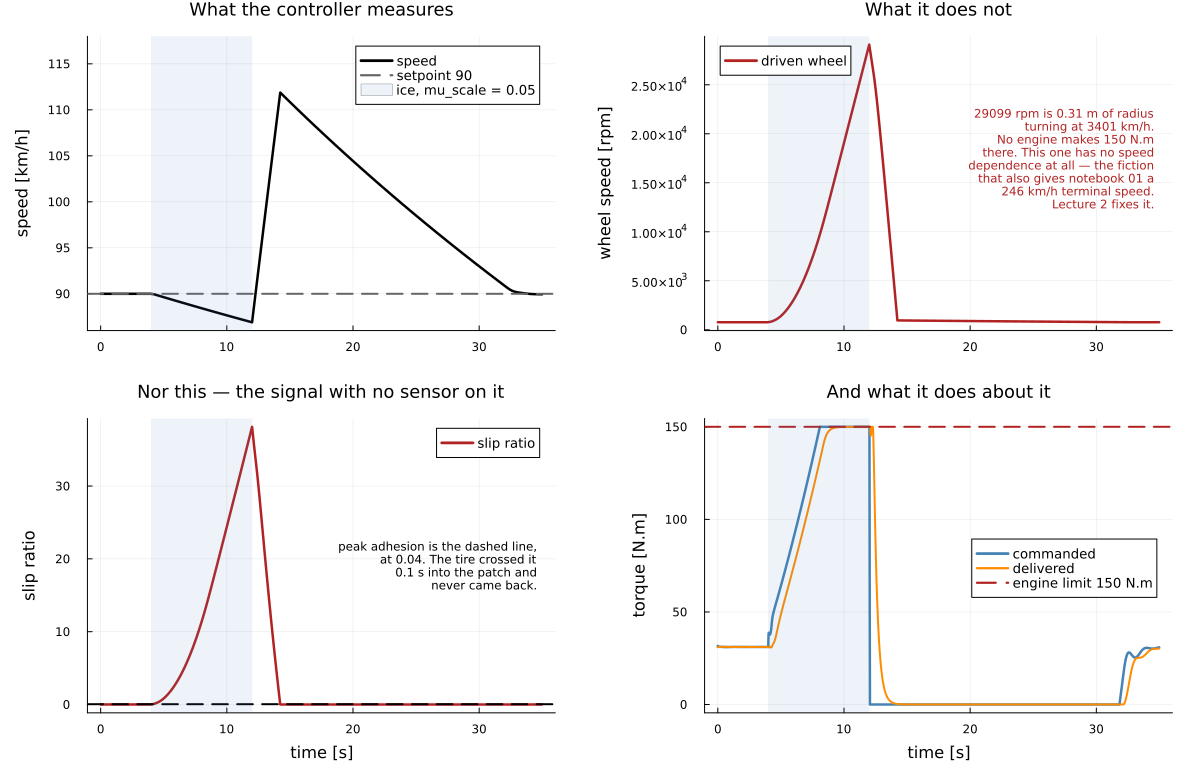

In [7]:
CRUISE       = 90.0    # km/h
MU_ICE       = 0.05
PATCH_START  = 4.0     # s
PATCH_LENGTH = 8.0     # s
PATCH_END    = PATCH_START + PATCH_LENGTH
J_W          = 1.0     # kg.m^2 — the road-wheel inertia the slip models ship

ice_patch(; kwargs...) = Scenarios.SlipCruiseTransient(;
    k = GAIN, Ti = T_I, Td = T_D, v_set = CRUISE, mu_low = MU_ICE,
    patch_start = PATCH_START, kwargs...)

blind = ice_patch(patch_duration = PATCH_LENGTH, stop = 45.0)

SPEED     = "loop.plant.v_kmh"
RPM       = "loop.plant.wheel_rpm"
SLIP      = "loop.plant.kappa"
FORCE     = "loop.plant.wheel.F_x"
COMMAND   = "loop.controller.y"
DELIVERED = "loop.plant.engine.limiter.y"

t_ice, v_ice = signal(blind, SPEED)
_, rpm_ice = signal(blind, RPM)
_, slip_ice = signal(blind, SLIP)
_, cmd_ice = signal(blind, COMMAND)
_, delivered_ice = signal(blind, DELIVERED)

at(run, path, moment) = (s = solution_of(run); s(moment, idxs = resolve(s, path)))

# Every number below is read off the solution's interpolant on one grid, so a peak and a value
# quoted at an instant cannot disagree with each other by a saved sample.
GRID = range(0.0, 45.0; length = 9001)
trace(run, path) = [at(run, path, moment) for moment in GRID]
fmt(x, dig) = dig == 0 ? string(round(Int, x)) : string(round(x, digits = dig))

println("                       entering the ice    leaving it     worst of the run")
for (name, path, dig) in (("speed [km/h]   ", SPEED, 2), ("wheel [rpm]    ", RPM, 0),
                          ("slip ratio     ", SLIP, 2), ("commanded [N.m]", COMMAND, 1))
    y = trace(blind, path)
    println("  ", name,
            "        ", rpad(fmt(at(blind, path, PATCH_START), dig), 20),
            rpad(fmt(at(blind, path, PATCH_END), dig), 15),
            fmt(maximum(y), dig))
end

speeds = trace(blind, SPEED)
slips = trace(blind, SLIP)
past_peak = GRID[findfirst(>(peak_kappa), slips)]
omega_max = maximum(trace(blind, RPM)) * 2pi / 60
recovered = (out = findlast(i -> GRID[i] > PATCH_END && abs(speeds[i] - CRUISE) > 0.5,
                            eachindex(GRID)); isnothing(out) ? 0.0 : GRID[out] - PATCH_END)

println()
println("  speed lost over the ice        ",
        round(CRUISE - at(blind, SPEED, PATCH_END), digits = 2), " km/h")
println("  slip past the adhesion peak    ", round(past_peak - PATCH_START, digits = 2),
        " s after the ice starts")
println("  peak speed after it            ", round(maximum(speeds), digits = 2), " km/h — ",
        round(maximum(speeds) - CRUISE, digits = 2), " km/h over the setpoint")
println("  back inside 0.5 km/h of 90     ", round(recovered, digits = 1),
        " s after the ice ends")
println("  energy stored in the wheel     ",
        round(0.5 * J_W * omega_max^2 / 1.0e6, digits = 2), " MJ, against ",
        round(0.5 * CAR.m * 25.0^2 / 1.0e6, digits = 2),
        " MJ for the whole car at 90 km/h")

# A two-second patch, for the record: the version of this scenario in which the loop's own
# measurement barely moves at all.
brief_patch = ice_patch(patch_duration = 2.0, stop = 30.0)
_, v2 = signal(brief_patch, SPEED)
_, rpm2 = signal(brief_patch, RPM)
_, slip2 = signal(brief_patch, SLIP)
println()
println("  two seconds of ice instead of eight: speed drops ",
        round(CRUISE - minimum(v2), digits = 2), " km/h, wheel reaches ",
        round(Int, maximum(rpm2)), " rpm at slip ", round(maximum(slip2), digits = 2))

VIEW = (0.0, 35.0)
shade!(p; label = "") = vspan!(p, [PATCH_START, PATCH_END];
                               color = :steelblue, alpha = 0.10, label = label)

speed_p = plot(keep(t_ice, v_ice, VIEW...)...; lw = 2.5, color = :black, label = "speed",
               ylabel = "speed [km/h]", ylims = (86, 118), legend = :topright,
               title = "What the controller measures")
hline!(speed_p, [CRUISE]; ls = :dash, lw = 2, color = :grey40, label = "setpoint 90")
shade!(speed_p; label = "ice, mu_scale = $MU_ICE")

wheel_p = plot(keep(t_ice, rpm_ice, VIEW...)...; lw = 2.5, color = :firebrick,
               label = "driven wheel", ylabel = "wheel speed [rpm]", legend = :topleft,
               title = "What it does not")
shade!(wheel_p)
annotate!(wheel_p, 34.5, 0.60 * maximum(rpm_ice),
          text("$(round(Int, maximum(rpm_ice))) rpm is $(CAR.r) m of radius\n" *
               "turning at $(round(Int, maximum(rpm_ice) * 2pi / 60 * CAR.r * 3.6)) km/h.\n" *
               "No engine makes 150 N.m\nthere. This one has no speed\n" *
               "dependence at all — the fiction\nthat also gives notebook 01 a\n" *
               "246 km/h terminal speed.\nLecture 2 fixes it.",
               8, :right, :firebrick))

slip_p = plot(keep(t_ice, slip_ice, VIEW...)...; lw = 2.5, color = :firebrick,
              label = "slip ratio", xlabel = "time [s]", ylabel = "slip ratio",
              legend = :topright, title = "Nor this — the signal with no sensor on it")
hline!(slip_p, [peak_kappa]; ls = :dash, lw = 2, color = :black, label = "")
shade!(slip_p)
annotate!(slip_p, 34.5, 0.50 * maximum(slips),
          text("peak adhesion is the dashed line,\n" *
               "at $(round(peak_kappa, digits = 2)). The tire crossed it\n" *
               "$(round(past_peak - PATCH_START, digits = 1)) s into the patch and\nnever came back.",
               8, :right, :black))

torque_p = plot(keep(t_ice, cmd_ice, VIEW...)...; lw = 2.5, color = :steelblue,
                label = "commanded", xlabel = "time [s]", ylabel = "torque [N.m]",
                legend = :right, title = "And what it does about it")
plot!(torque_p, keep(t_ice, delivered_ice, VIEW...)...; lw = 2, color = :darkorange,
      label = "delivered")
hline!(torque_p, [CAR.T_max]; ls = :dash, lw = 2, color = :firebrick,
       label = "engine limit $(round(Int, CAR.T_max)) N.m")
shade!(torque_p)

ice_fig = plot(speed_p, wheel_p, slip_p, torque_p; layout = (2, 2), size = (1200, 780))
save_figure(ice_fig, "10-ice-patch")
ice_fig

Read the top-left panel on its own and the loop looks fine. The speed sags by three km/h over
eight seconds of ice — less than a driver would lose on a gentle hill — and comes back. An
engineer handed only that trace, or a car handed only that trace, would report a controller
doing its job under a disturbance.

Now read the rest of the row. While the speed held within three km/h, **the wheel went to
29 000 rpm and the slip ratio to 38**. The tire crossed its adhesion peak within a tenth of a
second of the ice starting and never came back, and everything after that is a wheel skating
on a surface it is no longer gripping. In a real car that is the moment the steering goes light and the
back end starts to come round — the moment, in other words, that matters, and it is invisible
in the only signal this loop can see.

Worse, the loop did not merely fail to notice. It *drove* the failure. Look at the torque
panel: the speed error opened, the proportional term asked for more torque, the command climbed
to the engine's 150 N.m and stayed there. That torque went somewhere. It could not go into the
road, because the road would not take it, so it went into spinning up the wheel — and every
extra rpm of wheel took `mu` further down the wrong side of the curve, which opened the speed
error further, which asked for more torque. The plant's positive feedback loop from section 3
is now being driven by the controller's negative feedback loop, and the controller is winning.

And then the ice ends, and the bill arrives. The readout above puts 4.6 MJ into that spinning
wheel against the 0.44 MJ the whole car carries at 90 km/h — ten times over. The instant that
wheel finds grip, some of that energy goes into the car, and the car
is thrown 22 km/h over its setpoint and takes 20 seconds to come back. The size of the surge is
exaggerated here — see the note on the plot, and read the closing section — but its sign and
its cause are real, and it is why a spun wheel regaining traction is something drivers are
taught to be afraid of.

**You cannot control what you do not measure.** Every loop in this lecture has closed around a
measurement, and every one of them has been blind to everything else. Until now, nothing else
mattered. Here the thing that matters most — whether the tire is still attached to the road —
is not on the list.

## 5. What a friction-aware limit would have done

The fix is not a better tuning. It is a different piece of information.

Suppose the loop knew what the road could carry. Peak adhesion on this patch is
`mu_A * 0.05 * F_z = 343 N`, and that force reaches the contact patch through a 4:1 reduction
on a 0.31 m radius, so it corresponds to about 27 N.m at the engine. Cap the command there and
the tire is never asked for more than it has, so there is almost no surplus torque left over
to spin the wheel up with.

One honest caveat on the comparison below. `y_max` is a constant, so the cap is on for the
whole run, including the dry road either side of the patch — where 27 N.m is *less* than the
31 N.m it takes to hold 90 km/h, so the capped car is already half a km/h down when it reaches
the ice and never gets back to 90 afterwards. A real system moves the cap with the surface.
That is not a detail; it is the entire design problem, and it is what section 6 is about.

  peak force the ice can carry      343.2 N
  the engine torque that reaches it 26.6 N.m
  the torque that holds 90 km/h     31.08 N.m

                            lost on the ice   mean tire force   peak wheel    peak slip
  blind,  y_max = 150 N.m   3.1 km/h          242 N             29101 rpm     38.14
  capped, y_max = 26.6 N.m  1.99 km/h         275 N             1846 rpm      1.47

  the capped car reaches the ice at 89.47 km/h rather than 90, because its ceiling
  sits below the 31.1 N.m that holds 90 km/h on dry road


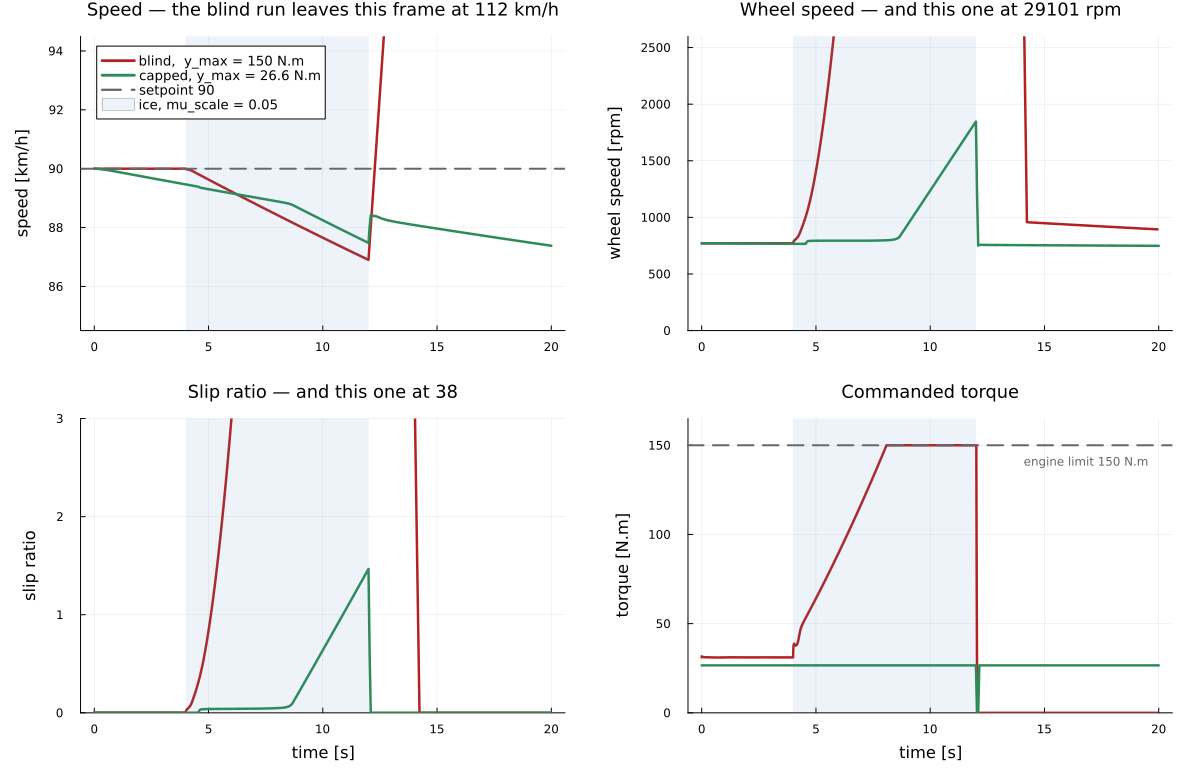

In [8]:
# Half the car's weight on the driven axle, which is the `F_z` the wheel model ships.
F_Z = CAR.m * CAR.g / 2
ICE_CEILING = MU_PEAK * MU_ICE * F_Z * CAR.r / CAR.i
HOLD_90 = (0.5 * CAR.rho * CAR.CdA * 25.0^2 + CAR.f_r * CAR.m * CAR.g) * CAR.r / CAR.i

println("  peak force the ice can carry      ", round(MU_PEAK * MU_ICE * F_Z, digits = 1), " N")
println("  the engine torque that reaches it ", round(ICE_CEILING, digits = 2), " N.m")
println("  the torque that holds 90 km/h     ", round(HOLD_90, digits = 2), " N.m")
println()

# `saveat` for the capped run only: it is a slow smooth decay that the solver crosses in very
# few steps, where the uncapped run's own steps are already dense.
capped = rerun(blind, "y_max" => ICE_CEILING; saveat = 0.05)

CONTRAST = (("blind,  y_max = $(round(Int, CAR.T_max)) N.m", blind, :firebrick),
            ("capped, y_max = $(round(ICE_CEILING, digits = 1)) N.m", capped, :seagreen))

on_ice = PATCH_START .<= GRID .<= PATCH_END

println("                            lost on the ice   mean tire force   peak wheel    peak slip")
for (name, run, _) in CONTRAST
    lost = at(run, SPEED, PATCH_START) - at(run, SPEED, PATCH_END)
    mean_force = sum(trace(run, FORCE)[on_ice]) / count(on_ice)
    println("  ", rpad(name, 26),
            rpad(string(round(lost, digits = 2), " km/h"), 18),
            rpad(string(round(Int, mean_force), " N"), 18),
            rpad(string(round(Int, maximum(trace(run, RPM))), " rpm"), 14),
            round(maximum(trace(run, SLIP)), digits = 2))
end
println()
println("  the capped car reaches the ice at ", round(at(capped, SPEED, PATCH_START), digits = 2),
        " km/h rather than 90, because its ceiling")
println("  sits below the ", round(HOLD_90, digits = 1), " N.m that holds 90 km/h on dry road")

LOOK = (0.0, 20.0)
leaves(path, dig) = fmt(maximum(trace(blind, path)), dig)
panels = (plot(; ylabel = "speed [km/h]", ylims = (84.5, 94.5), legend = :topleft,
                 title = "Speed — the blind run leaves this frame at $(leaves(SPEED, 0)) km/h"),
          plot(; ylabel = "wheel speed [rpm]", ylims = (0, 2600), legend = false,
                 title = "Wheel speed — and this one at $(leaves(RPM, 0)) rpm"),
          plot(; xlabel = "time [s]", ylabel = "slip ratio", ylims = (0, 3), legend = false,
                 title = "Slip ratio — and this one at $(leaves(SLIP, 0))"),
          plot(; xlabel = "time [s]", ylabel = "torque [N.m]", ylims = (0, 165),
                 legend = false, title = "Commanded torque"))

for (name, run, hue) in CONTRAST
    for (p, path) in zip(panels, (SPEED, RPM, SLIP, COMMAND))
        tt, yy = signal(run, path)
        plot!(p, keep(tt, yy, LOOK...)...; lw = 2.5, color = hue, label = name)
    end
end
hline!(panels[1], [CRUISE]; ls = :dash, lw = 2, color = :grey40, label = "setpoint 90")
hline!(panels[4], [CAR.T_max]; ls = :dash, lw = 2, color = :grey40, label = "")
annotate!(panels[4], 19.5, CAR.T_max - 9,
          text("engine limit $(round(Int, CAR.T_max)) N.m", 8, :right, :grey40))
shade!(panels[1]; label = "ice, mu_scale = $MU_ICE")
foreach(shade!, panels[2:end])

limited_fig = plot(panels...; layout = (2, 2), size = (1200, 780))
save_figure(limited_fig, "10-ice-patch-limited")
limited_fig

The capped run commands a fifth of the torque and **loses less speed doing it**: two km/h across
the ice against the blind run's three.

The middle column is where that comes from. Averaged over the eight seconds of ice, the capped
tire put *more* force on the road than the blind one did, while being asked for a fifth as much
torque. The extra 120 N.m the blind controller commanded did not reach the road, because the
road would not take it; it went into spinning the wheel, and the spinning wheel dragged `mu`
down the far side of the curve onto the sliding plateau, where it stayed for the rest of the
patch. More command, less force. That is the whole of traction control in one line.

Be precise about what the cap did and did not achieve. It did not hold the tire at its peak —
the capped run still ends the patch at a slip ratio of 1.5, which is nowhere near 0.04. A
constant ceiling cannot track a peak; it can only stop the command from running away from the
surface, and that turns out to be most of the benefit. The wheel peaks at 1 800 rpm rather than
29 000, the slip ratio at 1.5 rather than 38, and there is no surge when the ice ends because
there is no reservoir of wheel energy to empty into the car.

What it does not do is hold 90 km/h — on the ice, because nothing can, and on the dry road
afterwards, because a cap chosen for ice is far too tight for asphalt. Watch the green trace
drift downward past t = 12 s. A fixed cap is the right idea applied with the wrong information.

## 6. The two lessons, and where lecture 2 starts

**Production cruise control disengages when traction control intervenes**, and now the reason is
not a piece of folklore. It is not that the two controllers disagree politely about torque. It
is that the speed loop's error signal *actively asks for the thing that is destroying the car's
traction*, and it will go on asking as long as the error is open, because closing the error is
the only stopping condition it has. A loop that cannot see the failure it is causing must be
taken out of the chain by something that can.

**And the real fix is a second loop, not a better first one.** Everything section 5 got right
came from capping the torque at a value derived from the road. Everything it got wrong came
from that value being a constant. So make it a signal: an **inner loop** that measures slip and
regulates it — hold `kappa` near the peak, whatever the surface is doing — wrapped inside the
**outer loop** that measures speed and asks for torque. The outer loop stops commanding torque
and starts commanding a slip target; the inner loop decides what torque that takes, right now,
on this road.

That arrangement is **cascade control**, and it is where lecture 2 begins. It also answers a
question this lecture has dodged twice — in notebook 06, where the controller had to be told
the actuator's limit as a constant, and again here. A cascade does not need to be told. The
inner loop measures the thing the outer loop was guessing about.

## What this bought us

The plant has a failure mode that no amount of tuning reaches, and the loop cannot see it.

- **A saturating actuator is not always the engine.** Notebook 06's ceiling was a number in the
  engine's datasheet. This one is a property of the road surface, it moves while you drive, and
  no one tells you its current value.
- **Open-loop instability is a different category of problem from bad tuning.** `k`, `Ti` and
  `Td` decide how a loop drives a plant. They have nothing to say about what the plant does on
  its own, and past the friction peak what this plant does on its own is run away.
- **Every loop is blind to everything it does not measure**, and for nine notebooks that cost
  nothing. The first time it costs something, it costs the whole car. The question to carry out
  of a control course is not only *is my loop stable?* but *what is my loop not looking at?*

One thing this notebook gets wrong, and says so twice rather than hoping nobody notices: the
wheel speeds. 12 843 rpm is 1 501 km/h of tread surface, and 29 099 rpm is 3 401 km/h. No
engine delivers peak torque at those speeds — no engine delivers peak torque much past a few
thousand rpm — and this one does, because `Vehicle.IdealEngine` is a torque limit and a lag
with no speed dependence in it at all. It is the same fiction that gives notebook 01 a
246 km/h terminal speed, and it inflates everything downstream of the wheel speed in the same
direction: the slip ratios, the stored energy, and the size of the surge when grip returns.
Real wheelspin is violent, but the tread does not go supersonic. Putting an engine torque map
in place of that constant is the first thing **lecture 2** does.

That is the end of lecture 1. Ten notebooks ago the car had one equation and no controller.
It now has a wheel that can lose the road, an actuator that runs out, a measurement that is
noisy and sampled, and a controller whose every term has been taken apart and put back. What
it does not yet have is a second loop — and that turns out to be the answer to most of what is
still wrong with it.